In [2]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold
from generalized_contrastive_PCA import gcPCA
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

## Define Helpers and Functions

In [3]:
def reject_outliers(X, m=3, scaling=False):
    """
    Adapted from https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    Returns a boolean mask where True = 'Keep' and False = 'Outlier'.
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')

    if scaling:
        mad = np.median(np.abs(X - median), axis=0) * 1.4826
    else:
        mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    mask = (X >= lower_bound) & (X <= upper_bound)

    return mask


def reject_outliers_by_subject_channel(burst_dict, value_key='peak_amp_base', m=3, scaling=False):
    """Compute outlier mask separately within each subject x chennel group.

    Args:
        burst_dict (dictionary): Burst dictionary containing at least:
            - 'subject'
            - 'channel'
            - value_key
        
        value_key (str, optional): Name of the feature on which to reject outliers. Defaults to 'peak_amp_base'.
        m (float, optional): Number of MADs from the median used as the cutoff. Defaults to 3.
        scaling (bool, optional): If True, scale MAD by 1.4826. Defaults to False.
    
    Returns:
        group_mask: ndarray of bool, shape (n_bursts,). Global mask with True = keep, False = outlier.
    """

    values = np.asarray(burst_dict[value_key])
    subjects_arr = np.asarray(burst_dict['subject'])
    channels_arr = np.asarray(burst_dict['channel'])

    n = len(values)
    if not (len(subjects_arr) == n and len(channels_arr) == n):
        raise ValueError(f"'subject', 'channel', and '{value_key}' must have the same length." )
    
    group_mask = np.ones(n, dtype=bool)
    unique_subjects = np.unique(subjects_arr)

    for sub in unique_subjects:
        sub_idx = subjects_arr == sub
        sub_channels = np.unique(channels_arr[sub_idx])

        for ch in sub_channels:
            idx = sub_idx & (channels_arr == ch)

            # Reject within this subject x channel subset
            local_mask = reject_outliers(values[idx], m=m, scaling=scaling)

            # Write local decisions back into full-length mask
            group_mask[idx] = local_mask

    return group_mask

In [4]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

### Channel labels

In [5]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [6]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [7]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [8]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

In [13]:
outlier_mask = reject_outliers_by_subject_channel(
    all_bursts,
    value_key='peak_amp_base',
    m=3,
    scaling=False
    )

len_mask = len(outlier_mask)

correct_bursts = {
    key: (value[outlier_mask] if len(value) == len_mask else value)
    for key, value in all_bursts.items()
    }

# print(f"Original trials: {len(all_bursts['peak_amp_base'])}")
# print(f"Corrected trials: {len(correct_bursts['peak_amp_base'])}")
# print(f"Removed trials: {len(all_bursts['peak_amp_base']) - len(correct_bursts['peak_amp_base'])}")

### Select bursts corresponding to C3/C4 and all STN contacts

In [14]:
c_idx = (correct_bursts['channel']=='C3') | (correct_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in correct_bursts['channel']]

### Train a logistic regression on the beta burst waveform for sensorimotor cortex (C3,C4) Vs STN that undergo a gcPCA 

In [15]:
burst_times = correct_bursts['waveform_times'] * 1000 

In [16]:
on_idx = (correct_bursts['med']=='ON')
off_idx = (correct_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [17]:
"""
```scaling_method``` accepts: 
    - 'MAD-based',
    - 'Robust',
    - 'Standard'
"""
scaling_method = 'MAD-based'

area = c_idx
scaled_waveforms = np.zeros_like(correct_bursts['waveform'])
for subject in np.unique(correct_bursts['subject']):
    subj_idx = (correct_bursts['subject'] == subject)

    if scaling_method == 'Robust':
        """Perform a modified z-score based on median and IQR"""
        scaler = RobustScaler().fit(correct_bursts['waveform'][subj_idx & area])                # .fit() returns the median and IQR values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'Standard':
        """Perform a z-score based on mean and STD"""
        scaler = StandardScaler().fit(correct_bursts['waveform'][subj_idx & area])              # .fit() returns the mean and STD values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'MAD-based':
        """Perfom a modified z-score based on median and MAD"""
        median, mad = scaler_fit(correct_bursts['waveform'][subj_idx & area])                   # Scaler based on MAD
        scaled_waveforms[subj_idx, :] = scaler_transform(correct_bursts['waveform'][subj_idx], median, mad)

    else:
        raise AttributeError("Wrong scaling method. Valide options are ['MAD-based', 'Robust', 'Standard'].")

In [ ]:
# Subject-level cross-validation: split subjects into train/test groups - nbr percetile modifiable

n_splits = 10                   # Number of folds for cross-validation
n_bins = np.arange(1, 15, 1)    # Number of bins to use for each gcPC
cols = [0, 1, -2, -1]           # List of gcPC columns to consider

accuracy = []
var = []
for n_bin in n_bins:
    subjects_score = []
    for subject in subjects:
        subj_idx = (correct_bursts['subject']==subject) & area
        trials = np.unique(correct_bursts['trial'][subj_idx])

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)
        
        fold_score = []
        for fold_idx, (train_index, test_index) in enumerate(kf.split(trials)):
            train_bursts_idx = np.isin(correct_bursts['trial'], trials[train_index]) & subj_idx
            train_bursts_on_idx = train_bursts_idx & (correct_bursts['med']=='ON')
            train_bursts_off_idx = train_bursts_idx & (correct_bursts['med']=='OFF')
                
            # GCPCA model trained only on test set bursts of the current subject
            gcpca_model = gcPCA(method='v4', normalize_flag=False)                                                      # gcPCA model creation
            gcpca_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])        # gcPCA application on OFF/ON cortex
            
            # Project all bursts of the current subject into PC space using the trained model
            all_scores = scaled_waveforms @ gcpca_model.loadings_
            
            X = []
            y = []
            pc_bin_lims = np.zeros((len(cols), n_bin + 1))
            # Build trial-level feature matrix X and matching label vector y
            for trial in trials:
                # For each trial, count how many bursts fall into each bin for the current gcPC
                burst_idx = subj_idx & (correct_bursts["trial"]==trial)
                label = np.unique(correct_bursts["med"][burst_idx])[0]

                row = []
                for i, col in enumerate(cols):
                    # Compute percentile edges for each gcPC of interest across all bursts 
                    pc_bin_lims[i, :] = np.percentile(all_scores[train_bursts_idx, col], np.linspace(0, 100, n_bin + 1))

                    for idx in range(len(pc_bin_lims[i, :]) - 1):
                        # Count bursts whose gcPC score falls within the current percentile bin
                        count = len(np.where((all_scores[burst_idx, cols[i]] >= pc_bin_lims[i, idx]) &
                                            (all_scores[burst_idx, cols[i]] < pc_bin_lims[i, idx+1]))[0])
                        row.append(count)

                X.append(row)
                y.append(0 if label=='OFF' else 1)

            X = np.array(X)
            y = np.array(y)

            model = LOR(max_iter=10_000)
            model = model.fit(X[train_index, :], y[train_index])
            y_pred = model.predict(X[test_index, :])

            score = np.mean(y[test_index] == y_pred)
            print(f'Subject {subject} fold {fold_idx}: Score = {score:.3f}')
            fold_score.append(score)

        print(f'Subject {subject}: Mean Score = {np.mean(fold_score):.3f} ± {np.std(fold_score):.3f}')
        subjects_score.append(np.mean(fold_score))

    print(f'Overall Mean Score across subjects: {np.mean(subjects_score):.3f} ± {np.std(subjects_score):.3f}')
    accuracy.append(np.mean(subjects_score))
    var.append(np.std(subjects_score))
    print(n_bin)
    print(accuracy)
    print("\n")

c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 0: Score = 0.500
Subject s02 fold 1: Score = 0.750
Subject s02 fold 2: Score = 0.750


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 3: Score = 0.750
Subject s02 fold 4: Score = 0.500
Subject s02 fold 5: Score = 0.500


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


...

Subject s18 fold 5: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 6: Score = 1.000
Subject s18 fold 7: Score = 1.000
Subject s18 fold 8: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 9: Score = 1.000
Subject s18: Mean Score = 1.000 ± 0.000
Overall Mean Score across subjects: 0.837 ± 0.139
14
[np.float64(0.6446969696969697), np.float64(0.651969696969697), np.float64(0.777121212121212), np.float64(0.7872727272727272), np.float64(0.8190909090909091), np.float64(0.8251515151515153), np.float64(0.8433333333333334), np.float64(0.8372727272727274), np.float64(0.8569696969696969), np.float64(0.831969696969697), np.float64(0.8471212121212122), np.float64(0.8395454545454545), np.float64(0.8493939393939395), np.float64(0.8372727272727274)]




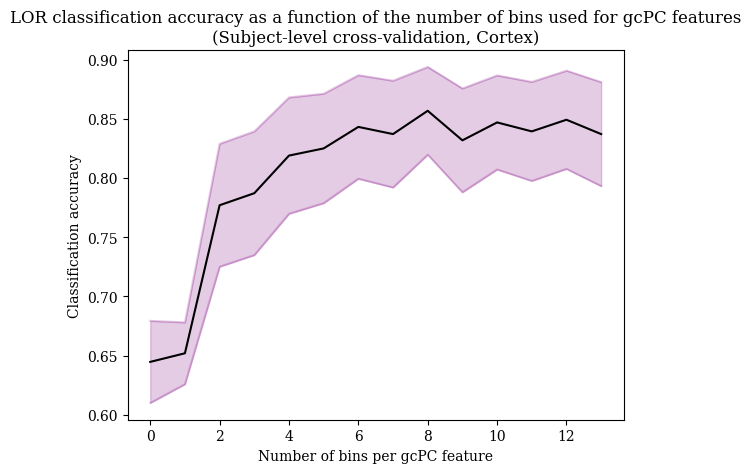

In [22]:
# Plot accuracy with error bars (standard deviation across folds) as a function of the number of bins used for gcPC features

upper = np.array(accuracy) + np.array(var) / np.sqrt(n_splits)
lower = np.array(accuracy) - np.array(var) / np.sqrt(n_splits)
plt.plot(accuracy, color='black')
plt.plot(upper, color='purple', alpha=0.2)
plt.plot(lower, color='purple',alpha=0.2)
plt.fill_between(n_bins-1, lower, upper, color='purple', alpha=0.2)
plt.xlabel('Number of bins per gcPC feature')
plt.ylabel('Classification accuracy')
plt.title('LOR classification accuracy as a function of the number of bins used for gcPC features\n(Subject-level cross-validation, Cortex)')
plt.show()